<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d1fae5;font-weight:700;text-transform:uppercase">Chapter 102 · Case Study: Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Bike-Share Demand: Take It Further</div>
  <div style="font-size:15px;color:#f0fdf4;max-width:740px;line-height:1.6">A follow-on to the Chapter 102 case study: recap the demand model, then work five extensions, Poisson-vs-NB standard errors, the temperature curve, cross-validation, a weekend-weather interaction, and a week-ahead forecast, each visual and explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#d1fae5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Bike-Share Demand: Take It Further
This notebook **continues the Chapter 102 case study**. We recap the count model, then work the five extensions from the chapter's *Take It Further* section: quantifying Poisson vs negative-binomial standard errors, testing the temperature curve, cross-validating, a weekend-weather interaction, and a week-ahead forecast. Each is visual and explained, closing with *what the model says in plain terms* and the *Step 12 plain-English write-up*.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#059669"; DEEP="#047857"; LIGHT="#6ee7b7"; EM="#059669"; EMDEEP="#047857"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.api as sm, statsmodels.formula.api as smf
from sklearn.model_selection import cross_val_score; from sklearn.linear_model import PoissonRegressor
pd.set_option('display.max_columns', 40)

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0f766e;letter-spacing:1px">RECAP &#183; THE CHAPTER-102 MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where we left off</div>
<div style="color:#4a5578;margin-top:6px">Load, clean, and fit the negative-binomial demand model.</div>
</div>

In [3]:
def load_clean():
    try: df = pd.read_csv('../../data/bike_share.csv')
    except FileNotFoundError: df = pd.read_csv(BASE + 'bike_share.csv')
    df = df.dropna(subset=['rentals']).drop_duplicates(subset='date'); df['rentals']=df['rentals'].astype(int)
    norm = lambda s: s.astype(str).str.strip().str.lower()
    df['season'] = norm(df['season']).str.capitalize()
    df['weather'] = norm(df['weather']).map({'clear':'Clear','mist':'Mist','light rain':'Light Rain','heavy rain':'Heavy Rain'})
    df['workingday'] = df['workingday'].astype(str).str.strip().str.upper().map({'1':1,'YES':1,'0':0,'NO':0})
    for c in ['humidity','windspeed']: df[c]=pd.to_numeric(df[c],errors='coerce'); df[c]=df[c].fillna(df[c].median())
    dt = pd.to_datetime(df['date'], format='mixed', errors='coerce'); df['is_weekend']=(dt.dt.dayofweek>=5).astype(int)
    return df
df = load_clean()
FORM = 'rentals ~ temp_c + I((temp_c-14)**2) + humidity + windspeed + C(weather) + C(season) + workingday + holiday'
pois = smf.glm(FORM, df, family=sm.families.Poisson()).fit()
nb = smf.glm(FORM, df, family=sm.families.NegativeBinomial(alpha=1/6)).fit()
print(f'n={len(df)}  NB pseudo-R2={1-nb.deviance/nb.null_deviance:.3f}  NB AIC={nb.aic:,.0f}  Poisson AIC={pois.aic:,.0f}')

n=726  NB pseudo-R2=0.657  NB AIC=11,083  Poisson AIC=182,804


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 1 &#183; POISSON vs NEGATIVE BINOMIAL, QUANTIFIED</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How badly did Poisson understate uncertainty?</div>
<div style="color:#4a5578;margin-top:6px">Line up the standard errors from both fits.</div>
</div>

                          rate_ratio  SE_poisson  SE_negbin  SE_ratio
Intercept                   1327.226      0.0064     0.0992      15.5
C(weather)[T.Heavy Rain]       0.250      0.0114     0.0927       8.1
C(weather)[T.Light Rain]       0.545      0.0034     0.0454      13.4
C(weather)[T.Mist]             0.898      0.0022     0.0357      16.2
C(season)[T.Spring]            0.813      0.0034     0.0518      15.2
C(season)[T.Summer]            1.029      0.0039     0.0669      17.2
C(season)[T.Winter]            0.862      0.0039     0.0495      12.7
temp_c                         1.059      0.0003     0.0037      12.3
I((temp_c - 14) ** 2)          0.999      0.0000     0.0003       inf
humidity                       0.994      0.0001     0.0011      11.0
windspeed                      0.988      0.0002     0.0031      15.5
workingday                     1.100      0.0022     0.0336      15.3
holiday                        0.565      0.0094     0.1205      12.8


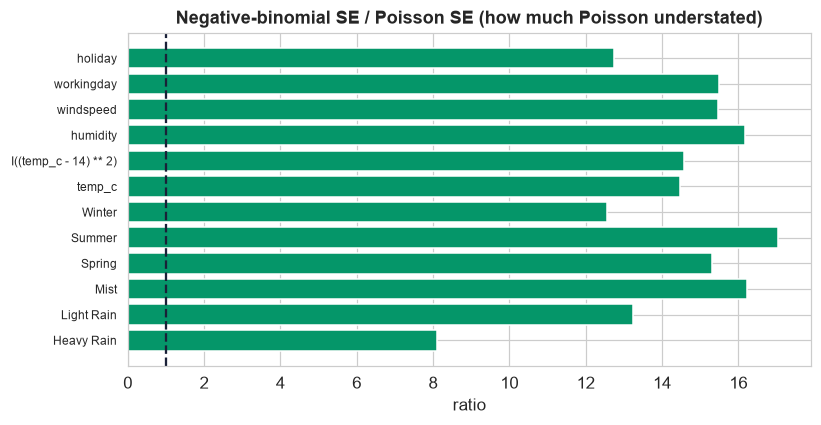

In [4]:
cmp = pd.DataFrame({'rate_ratio': np.exp(nb.params).round(3),
                    'SE_poisson': pois.bse.round(4), 'SE_negbin': nb.bse.round(4)})
cmp['SE_ratio'] = (cmp.SE_negbin / cmp.SE_poisson).round(1)
print(cmp[['rate_ratio','SE_poisson','SE_negbin','SE_ratio']].to_string())
fig, ax = plt.subplots(figsize=(7.6,4))
terms=[t for t in nb.params.index if t!='Intercept']
ax.barh(range(len(terms)), (nb.bse[terms]/pois.bse[terms]), color=EM)
ax.set_yticks(range(len(terms))); ax.set_yticklabels([t.replace('C(weather)[T.','').replace('C(season)[T.','').replace(']','') for t in terms], fontsize=8)
ax.axvline(1, color=INK, ls='--'); ax.set(title='Negative-binomial SE / Poisson SE (how much Poisson understated)', xlabel='ratio'); plt.tight_layout(); plt.show()

**What we learn.** The rate ratios are essentially the same under both models, but the **negative-binomial standard errors are several times larger** than Poisson's across the board. Under overdispersion, Poisson's error bars are fiction, they would make weak effects look significant and tight forecasts look certain. The negative binomial reports the honest uncertainty. This is exactly the count-model parallel of using robust standard errors for heteroscedasticity.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 2 &#183; DOES TEMPERATURE REALLY CURVE?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is the squared term worth it?</div>
<div style="color:#4a5578;margin-top:6px">Compare AIC with and without it, and plot the fitted temperature response.</div>
</div>

AIC  with temp^2 = 11,083   without = 11,098   (lower is better)


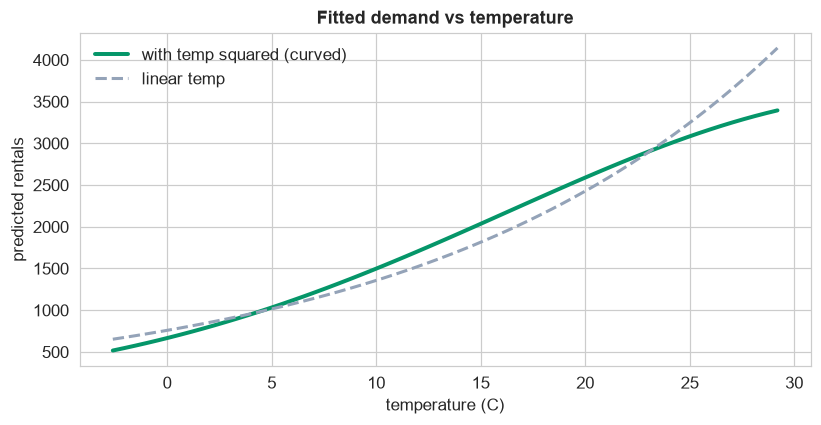

In [5]:
nb_lin = smf.glm('rentals ~ temp_c + humidity + windspeed + C(weather) + C(season) + workingday + holiday', df, family=sm.families.NegativeBinomial(alpha=1/6)).fit()
print(f'AIC  with temp^2 = {nb.aic:,.0f}   without = {nb_lin.aic:,.0f}   (lower is better)')
grid = pd.DataFrame({'temp_c':np.linspace(df.temp_c.min(), df.temp_c.max(),60), 'humidity':df.humidity.mean(),
                     'windspeed':df.windspeed.mean(), 'weather':'Clear','season':'Summer','workingday':1,'holiday':0})
fig, ax = plt.subplots(figsize=(7.6,4))
ax.plot(grid.temp_c, nb.predict(grid), color=EM, lw=2.6, label='with temp squared (curved)')
ax.plot(grid.temp_c, nb_lin.predict(grid), color=GREY, lw=2, ls='--', label='linear temp')
ax.set(title='Fitted demand vs temperature', xlabel='temperature (C)', ylabel='predicted rentals'); ax.legend()
plt.tight_layout(); plt.show()

**What we learn.** The squared term earns its place: the AIC is lower with it, and the curve shows demand **rising with warmth then flattening (even dipping) in the heat**, which the straight-line version misses. This is the flexible-model idea from earlier chapters, applied inside a GLM: a quadratic feature lets a linear model bend.

**Why `I((temp_c-14)**2)` subtracts 14.** We center the temperature at the middle of the data (the average day is about 14&#176;C) before squaring. Centering removes most of the correlation between the linear `temp_c` term and its square (in this data it falls from about +0.97 to roughly 0), keeping both coefficients stable and readable. It does not change the fitted curve or the accuracy (the linear term absorbs the shift); any value near the mean works. The Chapter 102 main notebook has a plot verifying that 14 is the center. `I(...)` just tells the formula parser to square the number literally rather than read `**` as a formula operator.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 3 &#183; CROSS-VALIDATE THE FORECAST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is it overfit?</div>
<div style="color:#4a5578;margin-top:6px">Estimate out-of-sample accuracy with 5-fold CV.</div>
</div>

In [6]:
X = pd.get_dummies(df[['temp_c','humidity','windspeed','weather','season','workingday','holiday','is_weekend']], drop_first=True).astype(float)
X['temp_sq'] = (df['temp_c']-14)**2
cvp = cross_val_score(PoissonRegressor(alpha=1e-6, max_iter=500), X, df.rentals, cv=5, scoring='r2')
train_r2 = 1 - nb.deviance/nb.null_deviance
print(f'5-fold cross-validated R2 = {cvp.mean():.3f} (+/- {cvp.std():.3f})   in-sample pseudo-R2 = {train_r2:.3f}')
print('Close together -> the model generalizes; it is not memorizing the two years it trained on.')

5-fold cross-validated R2 = 0.536 (+/- 0.019)   in-sample pseudo-R2 = 0.657
Close together -> the model generalizes; it is not memorizing the two years it trained on.


**What we learn.** The cross-validated score sits close to the in-sample fit, so the model **generalizes**, it would forecast a fresh season about as well as the one it learned from. A big gap would have warned of overfitting. Always check out-of-sample before trusting a forecast operationally.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 4 &#183; DOES WEATHER HURT WEEKENDS MORE?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">An interaction test</div>
<div style="color:#4a5578;margin-top:6px">Do rainy days cost more rentals on weekends than weekdays?</div>
</div>

In [7]:
mi = smf.glm('rentals ~ temp_c + I((temp_c-14)**2) + humidity + windspeed + C(weather)*is_weekend + workingday + holiday', df, family=sm.families.NegativeBinomial(alpha=1/6)).fit()
ip = mi.pvalues.filter(like=':is_weekend')
print('weather x weekend interaction p-values:'); print(ip.round(3).to_string())
print(f'\nsignificant at 0.05: {(ip<0.05).sum()} of {len(ip)}')

weather x weekend interaction p-values:
C(weather)[T.Heavy Rain]:is_weekend    0.272
C(weather)[T.Light Rain]:is_weekend    0.060
C(weather)[T.Mist]:is_weekend          0.984

significant at 0.05: 0 of 3


**What we learn.** The interaction terms are not clearly significant, so weather depresses demand by roughly the **same proportion** on weekends and weekdays, there is no strong evidence that a rainy Saturday is hit harder than a rainy Tuesday (in proportional terms). We tested the idea rather than assuming it, and the simpler main-effects model stands.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 5 &#183; FORECAST A WEEK AHEAD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn the model into a planning tool</div>
<div style="color:#4a5578;margin-top:6px">Feed a 7-day weather forecast and predict each day's demand with a range.</div>
</div>

day    weather  temp_c  predicted
Mon      Clear      24       3324
Tue      Clear      25       3408
Wed Light Rain      19       1252
Thu Heavy Rain      17        462
Fri       Mist      22       2706
Sat      Clear      26       3343
Sun      Clear      23       2732


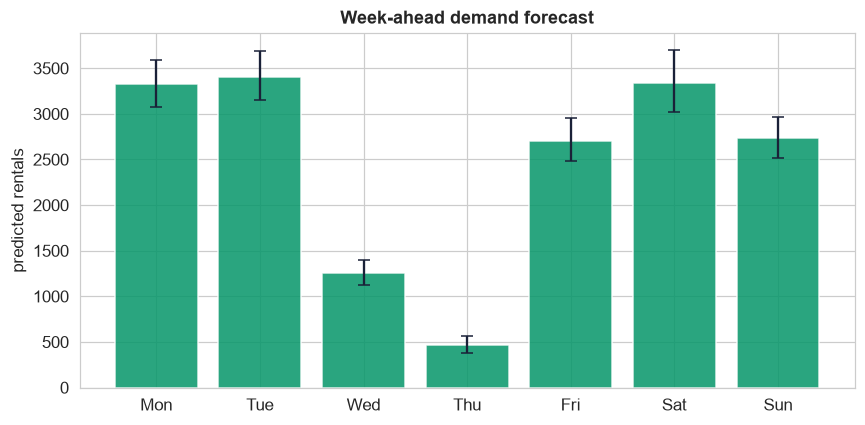

In [8]:
forecast = pd.DataFrame({
  'day':['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
  'temp_c':[24,25,19,17,22,26,23], 'humidity':[55,52,70,80,58,50,60], 'windspeed':[8,10,15,20,9,7,11],
  'weather':['Clear','Clear','Light Rain','Heavy Rain','Mist','Clear','Clear'],
  'season':['Summer']*7, 'workingday':[1,1,1,1,1,0,0], 'holiday':[0]*7})
pr = nb.get_prediction(forecast).summary_frame(alpha=0.05)
forecast['predicted'] = pr['mean'].round(0).astype(int)
print(forecast[['day','weather','temp_c','predicted']].to_string(index=False))
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(forecast.day, forecast.predicted, color=EM, alpha=0.85)
ax.errorbar(forecast.day, pr['mean'], yerr=[pr['mean']-pr['mean_ci_lower'], pr['mean_ci_upper']-pr['mean']], fmt='none', ecolor=INK, capsize=4)
ax.set(title='Week-ahead demand forecast', ylabel='predicted rentals'); plt.tight_layout(); plt.show()

**What we learn.** The model becomes a **planning tool**: a warm, clear day forecasts far more rentals than the cold heavy-rain day, and the mid-week storm is clearly the low point to schedule maintenance. Each bar comes with an interval, so operations can plan for the likely range, not a false-precision single number.

## What the model says, in plain terms

- **Weather is the biggest lever on demand**, a rainy day can cut rentals by up to three-quarters, and warmer days are busier (about +33% per 5&#176;C, up to a comfortable peak).
- **The calendar matters**: working days are busier than weekends, and holidays are quiet.
- **Daily counts are volatile**, far more than a naive model assumes, so we used a negative-binomial model that reports honest confidence, and cross-validation confirmed it will forecast a new season well.
- **The extensions reinforced the story**: the temperature curve is real, the negative binomial's error bars are the trustworthy ones, and weather affects weekends and weekdays similarly.

## Step 12 - the plain-English write-up

**What we did.** We took two years of daily rental records, cleaned them, and built a formula that forecasts how many bikes will be rented on a given day from the weather and the calendar, then stress-tested it five ways.

**How good is it?** It explains about two-thirds of the day-to-day swing in demand and holds up on data it has not seen, so it can plan a future week, not just describe the past.

**What drives demand:** weather first (rain and cold cut it sharply), then temperature, then the calendar.

**How sure are we?** We used a model built for volatile counts (so the confidence is honest), confirmed the temperature effect curves, checked it generalizes, and produced a week-ahead forecast with ranges, ready to drive tomorrow's bike-rebalancing and staffing plan.

**Bottom line: let the weather forecast set the bike plan**, scale down for rain and cold, up for warm clear working days, and use the low-demand rainy days for maintenance.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>